<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-1/HW1_322512690_21239353_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 - Deep Learning Winter 2024

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#**Part 1 : Binary Classification**

In [4]:
import pandas as pd

# Define the paths to your datasets
train_path = '/content/drive/MyDrive/HW-1/part1_train.csv'
test_path = '/content/drive/MyDrive/HW-1/part1_test.csv'

# Load the datasets
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Display the first few rows of the training dataset
# print(train_data.head())
# print(test_data.head())


# **In order to scale the data we need first to covnert non-numerical values into numerical represtnation. so what we do is we apply one-hot encoding in order to represnt them.**

In [ ]:

# Identify categorical columns that exist in both train and test datasets
categorical_columns = list(set(train_data.select_dtypes(include=['object']).columns) &
                           set(test_data.select_dtypes(include=['object']).columns))

# Extract target variable before encoding (assuming last column is the target)
y_train = train_data.iloc[:, -1]
y_test = test_data.iloc[:, -1]

#need to remove the '.' in order to make the data clear and now convert it to numerical.
y_test = test_data.iloc[:, -1].str.strip().str.replace('.', '', regex=False)
# Strip whitespace from target column values
y_train = y_train.str.strip()
y_test = y_test.str.strip()


# Define the mapping for target values
label_mapping = {"<=50K": 0, ">50K": 1}

# Apply the mappingt
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)


# Apply one-hot encoding separately (for training and test (without target))
train_data_encoded = pd.get_dummies(train_data, columns=categorical_columns)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_columns)

# Align columns between train and test datasets to handle mismatched categories
train_data_aligned, test_data_aligned = train_data_encoded.align(test_data_encoded, join='inner', axis=1)


# **Exctract features and exclude the target for training and test and scaling the data using the StandardScaler.**

In [ ]:

# Extract features (after alignment)
X_train = train_data_aligned.drop(columns=train_data_aligned.columns[-1])  # Drop target column
X_test = test_data_aligned.drop(columns=test_data_aligned.columns[-1])    # Drop target column

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # Print shapes to verify
# print("X_train_scaled shape:", X_train_scaled.shape)
# print("X_test_scaled shape:", X_test_scaled.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)


In [ ]:
# Convert data to PyTorch tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

Now we Print the distribution of yearly income for the individuals and the
percentage of them more / less than 50k/year

In [ ]:
# Compute distribution for y_train
unique, counts = torch.unique(y_train, return_counts=True)

# Print the distribution
print("Income Distribution in Training Data:")
for value, count in zip(unique, counts):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {count.item()}")

# Compute percentages
total = counts.sum().item()
percentages = (counts.float() / total) * 100

# Print the percentages
print("\nIncome Percentage in Training Data:")
for value, percent in zip(unique, percentages):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {percent.item():.2f}%")


Income Distribution in Training Data:
<=50K: 24719
>50K: 7841

Income Percentage in Training Data:
<=50K: 75.92%
>50K: 24.08%


We will implement our FFNN network with 2 hidden layers where our activation function in each layer is RELU. we also apply drouput which we saw increased the accuarcy in test (althougth the training didnt pass 79 which is true).

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)  # Hidden layer 1
        self.dropout1 = nn.Dropout(p=0.2)    # Dropout for regularization
        self.fc2 = nn.Linear(64, 32)         # Hidden layer 2
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(32, 2)          # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first layer
        x = F.relu(self.fc2(x))  # Activation function for second layer
        x = self.fc3(x)          # No activation for output layer (raw scores)
        return x


due to one hot encoding our input size increase to 51 so our input starts with this size and we chooose the layers size  (input_size, 64)  # Hidden layer 1 AND (64, 32) # Hidden layer 2 which gave us a good test accuarcy with mini batches size 32. (we tried other parameters but these paramaters fit in well with our network).

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Input size is the number of features (but its gone to 51 due to one-code being applied which increased it)
input_size = X_train.shape[1]

# Define the model and hyperamreters
model = FeedForwardNN(input_size)
learning_rate = 0.001
epochs = 10
batch_size = 32


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
#we make each epoch to go on the batch size and not the entire data
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_acc = []

train_loss = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Calculate accuracy for this batch
        _, predicted = torch.max(outputs, 1)  # Get predicted classes
        correct += (predicted == y_batch).sum().item()  # Count correct predictions
        total += y_batch.size(0)  # Total samples

    # Store epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy * 100:.2f}%")

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, test_predictions = torch.max(test_outputs, 1)

accuracy = (test_predictions == y_test).sum().item() / y_test.size(0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")




Epoch 1/10, Loss: 0.4318, Train Acc: 77.70%
Epoch 2/10, Loss: 0.4168, Train Acc: 78.18%
Epoch 3/10, Loss: 0.4151, Train Acc: 78.18%
Epoch 4/10, Loss: 0.4140, Train Acc: 78.34%
Epoch 5/10, Loss: 0.4130, Train Acc: 78.38%
Epoch 6/10, Loss: 0.4124, Train Acc: 78.48%
Epoch 7/10, Loss: 0.4118, Train Acc: 78.45%
Epoch 8/10, Loss: 0.4113, Train Acc: 78.54%
Epoch 9/10, Loss: 0.4104, Train Acc: 78.62%
Epoch 10/10, Loss: 0.4105, Train Acc: 78.50%
Test Accuracy: 80.10%


We can infer from the graph (LOSS and Accuracy ) that even after the first couple of epochs the Network fits well on the data, and is enough to early stop after it (third to fourth..) we can also see that the Train accuracy is less than the Test which is Normal due to FREZZING and droput...


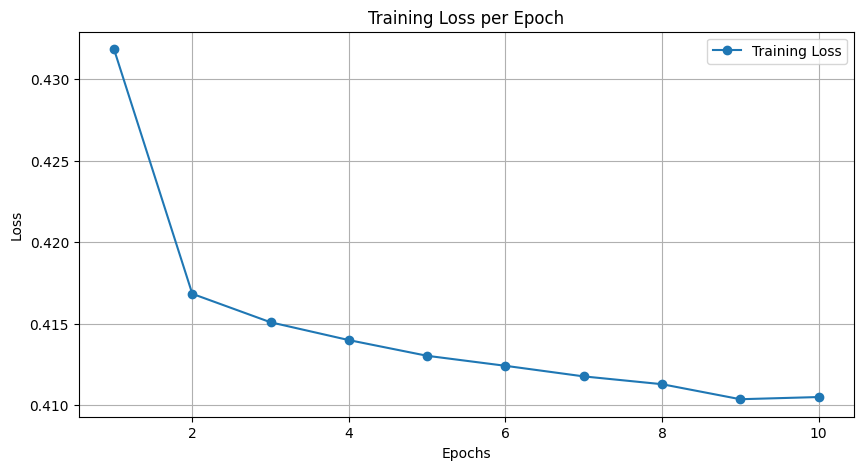

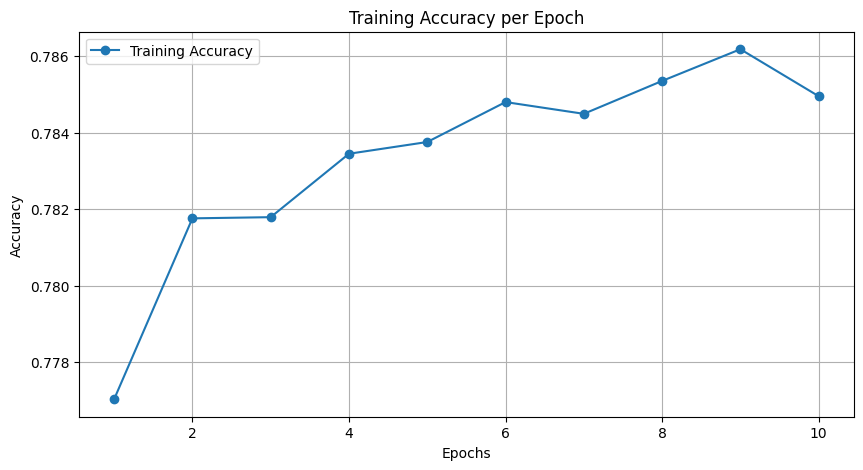

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label='Training Loss', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label='Training Accuracy', marker='o')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


# **QUESTION 2.**

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

Downloading the data and spliting the training and test

In [6]:
# Define transformations for preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Download and load the FashionMNIST dataset
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into training and validation sets
train_size = int(0.8 * len(train_data))  # 80% for training
val_size = len(train_data) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 17.6MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



**We will Create the Batch sizes in this Cell.**

In [7]:
# Create data loaders

from torch.utils.data import Subset

def filter_dataset(dataset, allowed_labels):
    indices = [i for i, (_, label) in enumerate(dataset) if label in allowed_labels]
    return Subset(dataset, indices)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


# Filter training and validation datasets for Network 1 (first 4 categories)
allowed_labels = [0, 1, 2, 3]
train_dataset_1 = filter_dataset(train_dataset, allowed_labels)
val_dataset_1 = filter_dataset(val_dataset, allowed_labels)
test_dataset_1 = filter_dataset(test_data, allowed_labels)

# Create DataLoaders for Network 1
train_loader_1 = DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True)
val_loader_1 = DataLoader(val_dataset_1, batch_size=batch_size, shuffle=False)
test_loader_1 = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=False)






Creating the First NN1. Since its parameters shouldnt pass 50k, our network will be : <br>
input size= 784 since flatteing (28X28) img to vector to output 60. <br>
parameters for  first layer is : input (60) and output 4 .<br>
 which the Total parameters will be (784X60)+ 60 (bias) + (60X4) + 4 (bias)  <=50k

In [8]:

class Network1(nn.Module):
    def __init__(self):
        super(Network1, self).__init__()
        self.fc1 = nn.Linear(784, 4)  # First layer: 784 → 60

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = self.fc1(x)  # Output
        return x


**Defining NN2   Since its parameters shouldnt pass 60k, our network will be :
input size= 784 since flatteing (28X28) img to vector to output (80):.
parameters for first layer is : input (80) and output (40) .<br>
second Layer: input (40) to output (20)
third Layer : input (20) to output (10) .
which the Total parameters will be 62,720+3,240+820+210=66,990

In [10]:
class Network2(nn.Module):
    def __init__(self):
        super(Network2, self).__init__()
        self.fc1 = nn.Linear(784, 256)  # First layer: 784 → 80
        self.fc2 = nn.Linear(256, 40)  # Second layer: 80 → 40
        self.fc3 = nn.Linear(40, 10)  # Third layer: 40 → 20

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output
        return x


**Now we traing the model **

In [11]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    # Store metrics
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        correct_train = 0
        total_train = 0
        running_loss = 0.0

        for images, labels in train_loader:
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update training metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct_train / total_train)

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss.append(val_running_loss / len(val_loader))
        val_acc.append(correct_val / total_val)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]*100:.2f}%, "
              f"Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]*100:.2f}%")

    return train_loss, val_loss, train_acc, val_acc



In [12]:
# Instantiate models
model1 = Network1()  # Network 1 for 4 categories
model2 = Network2()  # Network 2 for all 10 categories

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-4)  # With L2 regularization
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)

# Training parameters
epochs = 20

# Train both networks
print("Training Network 1:")
train_loss1, val_loss1, train_acc1, val_acc1 = train_model(model1, train_loader_1, val_loader_1, optimizer1, criterion, epochs)

print("\nTraining Network 2:")
train_loss2, val_loss2, train_acc2, val_acc2 = train_model(model2, train_loader, val_loader, optimizer2, criterion, epochs)


Training Network 1:
Epoch 1/20, Train Loss: 0.3227, Train Acc: 89.54%, Val Loss: 0.2264, Val Acc: 92.22%
Epoch 2/20, Train Loss: 0.2224, Train Acc: 92.89%, Val Loss: 0.2138, Val Acc: 92.88%
Epoch 3/20, Train Loss: 0.2097, Train Acc: 93.27%, Val Loss: 0.2005, Val Acc: 93.31%
Epoch 4/20, Train Loss: 0.2027, Train Acc: 93.55%, Val Loss: 0.1968, Val Acc: 93.62%
Epoch 5/20, Train Loss: 0.1980, Train Acc: 93.67%, Val Loss: 0.2026, Val Acc: 93.36%
Epoch 6/20, Train Loss: 0.1916, Train Acc: 93.90%, Val Loss: 0.1928, Val Acc: 93.42%
Epoch 7/20, Train Loss: 0.1907, Train Acc: 93.95%, Val Loss: 0.1974, Val Acc: 93.36%
Epoch 8/20, Train Loss: 0.1877, Train Acc: 94.12%, Val Loss: 0.1869, Val Acc: 93.79%
Epoch 9/20, Train Loss: 0.1848, Train Acc: 94.03%, Val Loss: 0.1902, Val Acc: 93.60%
Epoch 10/20, Train Loss: 0.1830, Train Acc: 94.08%, Val Loss: 0.1966, Val Acc: 93.46%
Epoch 11/20, Train Loss: 0.1812, Train Acc: 94.09%, Val Loss: 0.1980, Val Acc: 93.21%
Epoch 12/20, Train Loss: 0.1816, Train Acc:

In [13]:
def evaluate_model(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return running_loss / len(loader), accuracy



In [14]:
# Evaluate Network 1
test_loss1, test_acc1 = evaluate_model(model1, test_loader_1, criterion)
print(f"Network 1 - Test Loss: {test_loss1:.4f}, Test Accuracy: {test_acc1 * 100:.2f}%")

# Evaluate Network 2
test_loss2, test_acc2 = evaluate_model(model2, test_loader, criterion)
print(f"Network 2 - Test Loss: {test_loss2:.4f}, Test Accuracy: {test_acc2 * 100:.2f}%")


Network 1 - Test Loss: 0.2164, Test Accuracy: 92.97%
Network 2 - Test Loss: 0.3579, Test Accuracy: 88.50%


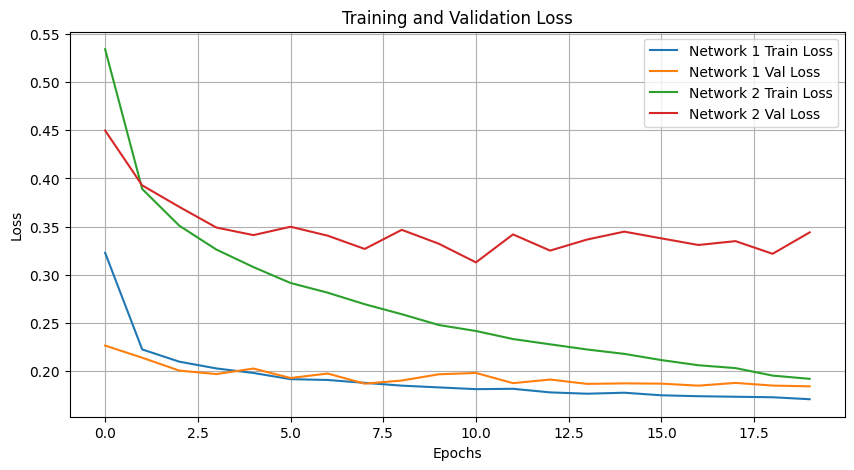

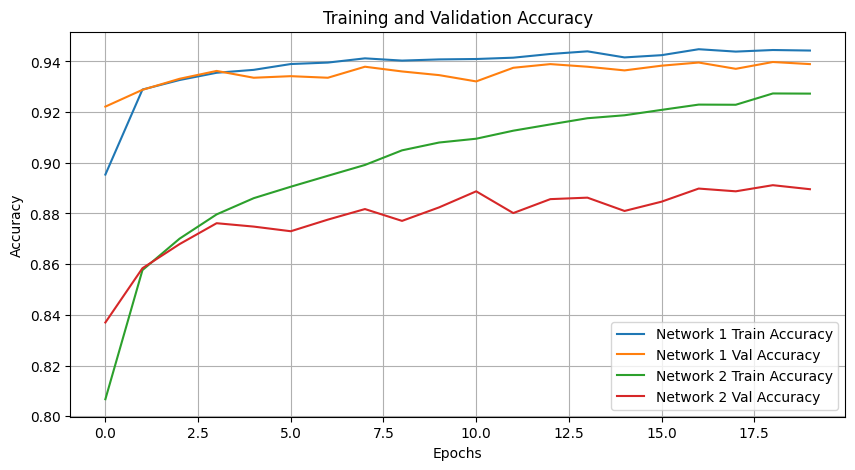

In [15]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss1, label='Network 1 Train Loss')
plt.plot(val_loss1, label='Network 1 Val Loss')
plt.plot(train_loss2, label='Network 2 Train Loss')
plt.plot(val_loss2, label='Network 2 Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc1, label='Network 1 Train Accuracy')
plt.plot(val_acc1, label='Network 1 Val Accuracy')
plt.plot(train_acc2, label='Network 2 Train Accuracy')
plt.plot(val_acc2, label='Network 2 Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()
